In [1]:
import os
os.chdir("..")

In [2]:
import numpy as np
import pandas as pd
import gymnasium as gym
import gym_trading_env
import random
import torch
from scipy import stats

from src.agent import MonteCarloAgent
from src.utils import load_trading_data, add_static_features
from src.visualize import (
    plot_convergence_comparison,
    create_comparison_table,
    print_comparison_table,
    plot_return_distributions
)

In [17]:
df = load_trading_data("data/GlobalExchangeData/indexProcessed.csv", symbol="GDAXI")
df = add_static_features(df)

# Filter the DataFrame
df_subset = df.loc["2016-01-01":"2021-12-31"]

In [4]:
def set_seed(seed, env=None):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    if env is not None:
        env.reset(seed=seed)

In [15]:
def run_multiple_seeds_collect_returns(agent_class, env_fn, agent_kwargs, num_episodes=500, seeds=5, eval_interval=50):
    """
    Run multiple seeds and collect ALL episode returns (not just final means).
    
    Args:
        agent_class: Agent class to instantiate
        env_fn: Function that returns environment
        agent_kwargs: Dictionary of arguments for agent initialization
        num_episodes: Number of episodes per seed
        seeds: Number of seeds to run
        eval_interval: Interval for printing progress
        
    Returns:
        List of episode returns for each seed
    """
    all_episode_returns = []
    
    for seed in range(seeds):
        print(f"Running seed {seed+1}/{seeds}...")
        
        env = env_fn()
        set_seed(seed, env)
        
        agent = agent_class(**agent_kwargs)
        
        # Train agent
        for episode in range(num_episodes):
            state, info = env.reset()
            done = truncated = False

            while not done and not truncated:
                action = agent.select_action(state)
                next_state, reward, done, truncated, info = env.step(action)
                agent.store_reward(reward)
                state = next_state
            
            agent.update()
            
            if (episode + 1) % eval_interval == 0:
                avg_return = np.mean(agent.episode_returns[-eval_interval:])
                print(f"  Episode {episode+1}/{num_episodes}, Avg Return (last {eval_interval}): {avg_return:.4f}")
        
        # Store all episode returns for this seed
        all_episode_returns.append(agent.episode_returns.copy())
        print(f"  Seed {seed+1} complete. Final 100 episodes mean: {np.mean(agent.episode_returns[-100:]):.4f}\n")
    
    return all_episode_returns

In [23]:
# Configuration
num_episodes = 500
num_seeds = 10
eval_interval = 250

# Create environment function
def make_env():
    env = gym.make(
        "TradingEnv",
        name="DAX",
        df=df_subset,
        positions=[-1, 0, 1],
        trading_fees=0.01/100,
        borrow_interest_rate=0.0003/100,
        verbose=0,
    )
    return env

# Get state and action dimensions
env_temp = make_env()
state, _ = env_temp.reset()
state_dim = len(state) if isinstance(state, (list, np.ndarray)) else state.shape[0]
action_dim = env_temp.action_space.n
print(f"State dimension: {state_dim}")
print(f"Action dimension: {action_dim}")

State dimension: 6
Action dimension: 3


In [24]:
# Run Random Trading baseline
print("TRAINING: Random Trading (Baseline)")
from src.agent import RandomTradingAgent

random_returns = run_multiple_seeds_collect_returns(
    agent_class=RandomTradingAgent,
    env_fn=make_env,
    agent_kwargs={'state_dim': state_dim, 'action_dim': action_dim},
    num_episodes=num_episodes,
    seeds=num_seeds,
    eval_interval=eval_interval
)

TRAINING: Random Trading (Baseline)
Running seed 1/10...
  Episode 250/500, Avg Return (last 250): -0.1939
  Episode 500/500, Avg Return (last 250): -0.2089
  Seed 1 complete. Final 100 episodes mean: -0.2577

Running seed 2/10...
  Episode 250/500, Avg Return (last 250): -0.2022
  Episode 500/500, Avg Return (last 250): -0.1897
  Seed 2 complete. Final 100 episodes mean: -0.1753

Running seed 3/10...
  Episode 250/500, Avg Return (last 250): -0.2161
  Episode 500/500, Avg Return (last 250): -0.1639
  Seed 3 complete. Final 100 episodes mean: -0.1945

Running seed 4/10...
  Episode 250/500, Avg Return (last 250): -0.2004
  Episode 500/500, Avg Return (last 250): -0.1714
  Seed 4 complete. Final 100 episodes mean: -0.1582

Running seed 5/10...
  Episode 250/500, Avg Return (last 250): -0.1957
  Episode 500/500, Avg Return (last 250): -0.2444
  Seed 5 complete. Final 100 episodes mean: -0.2004

Running seed 6/10...
  Episode 250/500, Avg Return (last 250): -0.2289
  Episode 500/500, Avg 

In [25]:
# Run REINFORCE (no baseline)
print("TRAINING: REINFORCE (without baseline)")

reinforce_returns = run_multiple_seeds_collect_returns(
    agent_class=MonteCarloAgent,
    env_fn=make_env,
    agent_kwargs={'state_dim': state_dim, 'action_dim': action_dim, 'gamma': 0.99, 'lr': 1e-3, 'use_baseline': False},
    num_episodes=num_episodes,
    seeds=num_seeds,
    eval_interval=eval_interval
)

TRAINING: REINFORCE (without baseline)
Running seed 1/10...
  Episode 250/500, Avg Return (last 250): 0.2059
  Episode 500/500, Avg Return (last 250): 0.5126
  Seed 1 complete. Final 100 episodes mean: 0.5441

Running seed 2/10...
  Episode 250/500, Avg Return (last 250): 0.1712
  Episode 500/500, Avg Return (last 250): 0.3702
  Seed 2 complete. Final 100 episodes mean: 0.3773

Running seed 3/10...
  Episode 250/500, Avg Return (last 250): 0.3142
  Episode 500/500, Avg Return (last 250): 0.8153
  Seed 3 complete. Final 100 episodes mean: 0.8558

Running seed 4/10...
  Episode 250/500, Avg Return (last 250): 0.1633
  Episode 500/500, Avg Return (last 250): 0.6921
  Seed 4 complete. Final 100 episodes mean: 0.7151

Running seed 5/10...
  Episode 250/500, Avg Return (last 250): 0.1961
  Episode 500/500, Avg Return (last 250): 0.6355
  Seed 5 complete. Final 100 episodes mean: 0.5726

Running seed 6/10...
  Episode 250/500, Avg Return (last 250): 0.2949
  Episode 500/500, Avg Return (last 

In [26]:
# Run REINFORCE (with baseline)
print("TRAINING: REINFORCE (with baseline)")

reinforce_baseline_returns = run_multiple_seeds_collect_returns(
    agent_class=MonteCarloAgent,
    env_fn=make_env,
    agent_kwargs={'state_dim': state_dim, 'action_dim': action_dim, 'gamma': 0.99, 'lr': 1e-3, 'use_baseline': True},
    num_episodes=num_episodes,
    seeds=num_seeds,
    eval_interval=eval_interval
)

TRAINING: REINFORCE (with baseline)
Running seed 1/10...
  Episode 250/500, Avg Return (last 250): 0.1614
  Episode 500/500, Avg Return (last 250): 0.6544
  Seed 1 complete. Final 100 episodes mean: 0.7260

Running seed 2/10...
  Episode 250/500, Avg Return (last 250): 0.3623
  Episode 500/500, Avg Return (last 250): 0.8552
  Seed 2 complete. Final 100 episodes mean: 0.8099

Running seed 3/10...
  Episode 250/500, Avg Return (last 250): 0.2464
  Episode 500/500, Avg Return (last 250): 0.7683
  Seed 3 complete. Final 100 episodes mean: 0.8137

Running seed 4/10...
  Episode 250/500, Avg Return (last 250): 0.3718
  Episode 500/500, Avg Return (last 250): 0.8375
  Seed 4 complete. Final 100 episodes mean: 0.8865

Running seed 5/10...
  Episode 250/500, Avg Return (last 250): 0.2587
  Episode 500/500, Avg Return (last 250): 0.5575
  Seed 5 complete. Final 100 episodes mean: 0.5692

Running seed 6/10...
  Episode 250/500, Avg Return (last 250): 0.1747
  Episode 500/500, Avg Return (last 250

In [27]:
# Generate comparison table
comparison_table = create_comparison_table(
    random_returns,
    reinforce_returns,
    reinforce_baseline_returns
)
print_comparison_table(comparison_table)


METHOD COMPARISON
              Method Mean Return (final) Std Dev (final)             95% CI Sharpe Ratio Max Drawdown Win Rate (%)
      Random Trading             -0.1925          0.0379 [-0.2197, -0.1654]      -8.0677    -961.0015        30.48
           REINFORCE              0.6231          0.1745   [0.4983, 0.7480]      18.6067     -15.6733        87.94
REINFORCE + Baseline              0.8177          0.1360   [0.7204, 0.9149]      20.5163     -12.8241        88.06



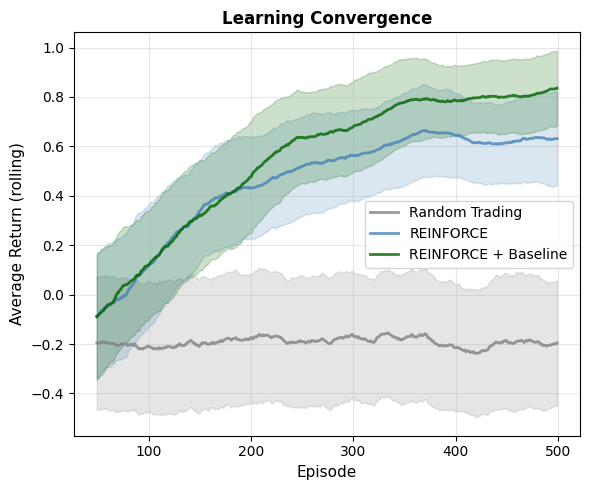

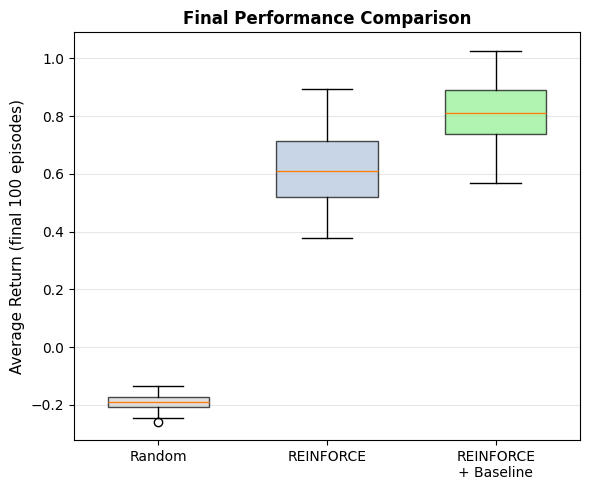

In [28]:
# Plot convergence comparison with confidence intervals
plot_convergence_comparison(
    random_returns,
    reinforce_returns,
    reinforce_baseline_returns,
    window=50,
    save_path="report/figures/convergence.png"
)

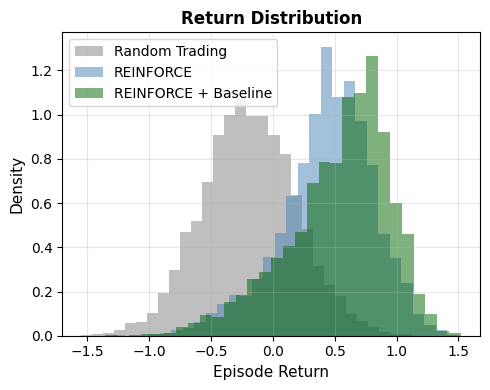

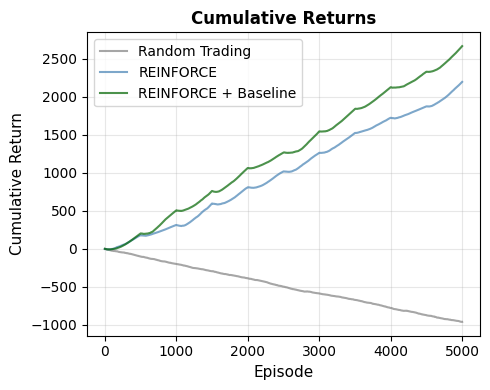

In [29]:
# Plot return distributions
plot_return_distributions(
    random_returns,
    reinforce_returns,
    reinforce_baseline_returns,
    save_path="report/figures/return.png"
)

In [35]:
import json
with open("data/returns.json", 'w') as fp:
    json.dump({
                "random_returns": random_returns,
                "reinforce_returns": reinforce_returns,
                "reinforce_baseline_returns": reinforce_baseline_returns
    }, fp)

In [44]:
' & '.join(['0.8177 '     ,   ' 0.1360'  , '[0.7204, 0.9149]'    ,  '20.5163'  ,   '-12.8241 ',      ' 88.06'])

'0.8177  &  0.1360 & [0.7204, 0.9149] & 20.5163 & -12.8241  &  88.06'

In [45]:
len(df_subset)

1366

Architecture diagram saved to report/figures/model_architecture.png


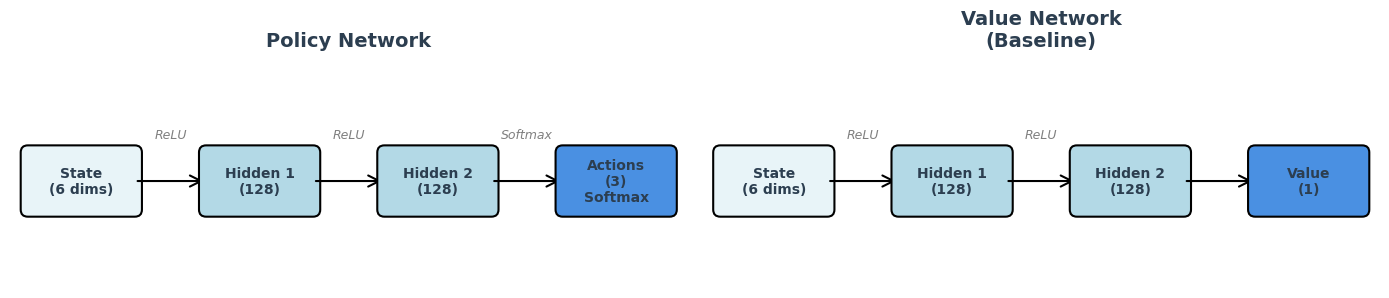

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

def create_architecture_diagram(save_path="report/figures/model_architecture.png"):
    """
    Create a simple diagram showing the neural network architecture
    for the REINFORCE agent (policy network and value network).
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Common parameters
    layer_width = 1.5
    layer_height = 0.8
    layer_spacing = 2.5
    y_center = 0
    
    # Colors
    input_color = '#E8F4F8'
    hidden_color = '#B3D9E6'
    output_color = '#4A90E2'
    text_color = '#2C3E50'
    
    def draw_network(ax, title, output_size, output_label):
        """Draw a neural network diagram"""
        layers = [
            ('State\n(6 dims)', 6, input_color),
            ('Hidden 1\n(128)', 128, hidden_color),
            ('Hidden 2\n(128)', 128, hidden_color),
            (output_label, output_size, output_color)
        ]
        
        x_positions = [0, layer_spacing, 2*layer_spacing, 3*layer_spacing]
        
        # Draw layers
        for i, (label, size, color) in enumerate(layers):
            x = x_positions[i]
            
            # Draw layer box
            box = FancyBboxPatch(
                (x - layer_width/2, y_center - layer_height/2),
                layer_width, layer_height,
                boxstyle="round,pad=0.1",
                facecolor=color,
                edgecolor='black',
                linewidth=1.5
            )
            ax.add_patch(box)
            
            # Add label
            ax.text(x, y_center, label, 
                   ha='center', va='center', 
                   fontsize=10, fontweight='bold',
                   color=text_color)
            
            # Draw arrows between layers
            if i < len(layers) - 1:
                arrow = FancyArrowPatch(
                    (x + layer_width/2, y_center),
                    (x_positions[i+1] - layer_width/2, y_center),
                    arrowstyle='->', 
                    mutation_scale=20,
                    linewidth=1.5,
                    color='black'
                )
                ax.add_patch(arrow)
        
        # Add activation labels
        ax.text(layer_spacing/2, y_center + 0.6, 'ReLU', 
               ha='center', fontsize=9, style='italic', color='gray')
        ax.text(1.5*layer_spacing, y_center + 0.6, 'ReLU', 
               ha='center', fontsize=9, style='italic', color='gray')
        
        if 'Softmax' in output_label:
            ax.text(2.5*layer_spacing, y_center + 0.6, 'Softmax', 
                   ha='center', fontsize=9, style='italic', color='gray')
        
        ax.set_xlim(-1, 3*layer_spacing + 1)
        ax.set_ylim(-1.5, 1.5)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20, color=text_color)
    
    # Draw Policy Network
    draw_network(ax1, 'Policy Network', 3, 'Actions\n(3)\nSoftmax')
    
    # Draw Value Network
    draw_network(ax2, 'Value Network\n(Baseline)', 1, 'Value\n(1)')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Architecture diagram saved to {save_path}")
    plt.show()

# Generate the architecture diagram
create_architecture_diagram()
